# Student Performance Analysis — Data Cleaning & Exploratory Data Analysis (EDA)

This notebook walks through:
1. Loading the dataset
2. Initial inspection (shape, types, missing values, duplicates)
3. Data cleaning (handling duplicates, fixing inconsistent values, type corrections)
4. Exploratory Data Analysis (descriptive stats, distributions, correlations) using **pandas**, **NumPy**, **Matplotlib**, and **Seaborn**

> Update the `FILE_PATH` variable in the next cell if your CSV is located somewhere else.

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [4]:
# 2. Load the dataset
FILE_PATH = r"C:\Users\ARPIT TYAGI\OneDrive\Desktop\NIIT\4\Student_Performance_Analysis_Fully_Modified.csv"
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
df.head()

Shape: (25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,20,Female,Private,High School,1.1,93.8,yes,15-30 min,yes,Group Study,71.2,92.4,79.5,81.0,A
1,2,17,Male,Private,Diploma,7.4,91.7,no,30-60 min,yes,Coaching,55.1,70.3,79.9,68.4,C
2,3,19,Male,Private,High School,7.0,100.0,no,30-60 min,no,Group Study,80.6,62.9,44.9,62.8,C
3,4,19,Male,Private,Diploma,1.6,79.9,no,15-30 min,no,Self Study,65.6,57.1,91.6,71.4,B
4,5,18,Male,Private,Graduate,1.9,99.0,yes,15-30 min,no,Self Study,92.9,83.3,83.5,86.6,A


## 3. Initial Inspection

Check data types, missing values, and basic statistics before cleaning.

In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

In [4]:
# Missing values per column
df.isnull().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [5]:
# Summary statistics for numeric columns
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,17.450200,4.845652,77.920892,69.555432,69.862300,69.655040,69.690852
std,4323.56215,1.443081,1.940871,11.606629,14.547803,14.649044,14.662475,9.387447
min,1.00000,15.000000,1.000000,40.000000,20.000000,20.000000,20.000000,30.000000
25%,3743.75000,16.000000,3.500000,70.000000,59.600000,60.000000,59.800000,63.400000
50%,7461.50000,17.000000,4.800000,78.100000,69.800000,70.200000,69.900000,69.900000
75%,11252.00000,18.250000,6.200000,86.200000,79.700000,80.100000,79.900000,76.300000
max,15000.00000,20.000000,12.000000,100.000000,100.000000,100.000000,100.000000,98.800000


In [6]:
# Summary for categorical/object columns
df.describe(include='object')

,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method,final_grade
count,25000,25000,25000,25000,25000,25000,25000,25000
unique,2,2,4,2,4,2,4,5
top,Male,Private,High School,yes,<15 min,no,Self Study,B
freq,14392,16905,8451,18014,8705,14759,9314,9037


## 4. Data Cleaning

### 4.1 Remove fully duplicated rows
First we check for rows that are exact duplicates across **all** columns.

In [7]:
# Check for fully duplicated rows
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes}")

# Drop them if any exist
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping full duplicates:", df.shape)

Fully duplicated rows: 0
Shape after dropping full duplicates: (25000, 16)


### 4.2 Check for duplicate IDs

Even if full rows aren't duplicated, the same `student_id` might appear more than once
(e.g. due to merging or re-entry errors). Let's check.

In [8]:
dup_id_count = df['student_id'].duplicated().sum()
print(f"Number of rows with a duplicated student_id: {dup_id_count}")
print(f"Unique student_ids: {df['student_id'].nunique()} out of {len(df)} rows")

# Show a sample of duplicated IDs
dup_ids = df[df['student_id'].duplicated(keep=False)].sort_values('student_id')
dup_ids.head(10)

Number of rows with a duplicated student_id: 10000
Unique student_ids: 15000 out of 25000 rows


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
1,2,17,Male,Private,Diploma,7.4,91.7,no,30-60 min,yes,Coaching,55.1,70.3,79.9,68.4,C
17524,2,16,Male,Private,Diploma,5.7,94.3,yes,<15 min,no,Self Study,60.5,48.9,57.3,55.6,D
23867,2,19,Male,Private,Postgraduate,5.3,90.4,yes,>60 min,no,Self Study,84.1,95.4,57.8,79.1,B
17372,2,20,Female,Public,Postgraduate,4.6,79.9,yes,<15 min,no,Self Study,51.1,58.3,67.7,59.0,D
2,3,19,Male,Private,High School,7.0,100.0,no,30-60 min,no,Group Study,80.6,62.9,44.9,62.8,C
21076,3,18,Male,Public,Graduate,6.3,78.4,yes,30-60 min,yes,Group Study,53.4,53.3,79.2,62.0,C
4,5,18,Male,Private,Graduate,1.9,99.0,yes,15-30 min,no,Self Study,92.9,83.3,83.5,86.6,A
24422,5,17,Male,Private,Postgraduate,1.1,98.3,no,15-30 min,no,Coaching,86.3,50.0,59.3,65.2,C
15557,5,17,Female,Private,Postgraduate,5.0,89.6,no,<15 min,yes,Coaching,47.9,87.9,67.7,67.8,C
16264,6,16,Male,Private,Graduate,2.5,82.4,yes,15-30 min,yes,Coaching,92.1,83.7,71.7,82.5,A


**Note:** If `student_id` is duplicated but the rest of the row differs, these may represent
different records that were assigned the same ID by mistake, or repeated
measurements for the same student. Decide based on context:

- If each row should represent a *unique student*, you may want to keep only the
  first occurrence per `student_id` (uncomment the line below).
- If repeated records are valid (e.g., multiple terms/tests per student), leave them as is.

In [9]:
# OPTIONAL: keep only the first record per student_id
# df = df.drop_duplicates(subset='student_id', keep='first').reset_index(drop=True)
# print("Shape after deduplicating by student_id:", df.shape)

### 4.3 Standardize categorical text values

Trim whitespace and fix inconsistent capitalization in text/categorical columns.

In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

# Show unique values for each categorical column to spot inconsistencies
for col in cat_cols:
    print(f"\n{col}: {sorted(df[col].unique())}")

Categorical columns: ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'final_grade']

gender: ['Female', 'Male']

school_type: ['Private', 'Public']

parent_education: ['Diploma', 'Graduate', 'High School', 'Postgraduate']

internet_access: ['no', 'yes']

travel_time: ['15-30 min', '30-60 min', '<15 min', '>60 min']

extra_activities: ['no', 'yes']

study_method: ['Coaching', 'Group Study', 'Online Courses', 'Self Study']

final_grade: ['A', 'B', 'C', 'D', 'F']


/tmp/ipykernel_584/2311074504.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


### 4.4 Handle missing values

Although the initial check showed no missing values, this step is included so the
notebook is reusable on similar datasets that *do* have gaps.

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:\n", missing if not missing.empty else "None")

# Example strategy (only runs if missing values exist):
# - Numeric columns -> fill with median
# - Categorical columns -> fill with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nRemaining missing values:", df.isnull().sum().sum())

Columns with missing values:
 None



Remaining missing values: 0


### 4.5 Check value ranges & fix out-of-range values

Scores and percentages should logically fall within sensible bounds
(e.g., 0–100). Attendance and study hours should also be non-negative.

In [12]:
# Columns expected to be within 0-100
score_cols = ['math_score', 'science_score', 'english_score', 'overall_score', 'attendance_percentage']

for col in score_cols:
    out_of_range = df[(df[col] < 0) | (df[col] > 100)]
    print(f"{col}: {len(out_of_range)} out-of-range values "
          f"(min={df[col].min()}, max={df[col].max()})")

# Study hours and age should be positive and within a reasonable range
print(f"\nstudy_hours: min={df['study_hours'].min()}, max={df['study_hours'].max()}")
print(f"age: min={df['age'].min()}, max={df['age'].max()}")

math_score: 0 out-of-range values (min=20.0, max=100.0)
science_score: 0 out-of-range values (min=20.0, max=100.0)
english_score: 0 out-of-range values (min=20.0, max=100.0)
overall_score: 0 out-of-range values (min=30.0, max=98.8)
attendance_percentage: 0 out-of-range values (min=40.0, max=100.0)

study_hours: min=1.0, max=12.0
age: min=15, max=20


In [13]:
# If any out-of-range values were found, clip them to valid bounds (0-100)
for col in score_cols:
    df[col] = df[col].clip(lower=0, upper=100)

print("Cleaning of score ranges complete.")

Cleaning of score ranges complete.


### 4.6 Final check after cleaning

In [14]:
print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
df.head()

Final shape: (25000, 16)
Duplicate rows: 0
Total missing values: 0


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,20,Female,Private,High School,1.1,93.8,yes,15-30 min,yes,Group Study,71.2,92.4,79.5,81.0,A
1,2,17,Male,Private,Diploma,7.4,91.7,no,30-60 min,yes,Coaching,55.1,70.3,79.9,68.4,C
2,3,19,Male,Private,High School,7.0,100.0,no,30-60 min,no,Group Study,80.6,62.9,44.9,62.8,C
3,4,19,Male,Private,Diploma,1.6,79.9,no,15-30 min,no,Self Study,65.6,57.1,91.6,71.4,B
4,5,18,Male,Private,Graduate,1.9,99.0,yes,15-30 min,no,Self Study,92.9,83.3,83.5,86.6,A


---
## 5. Exploratory Data Analysis (EDA)

Now that the data is clean, let's explore patterns and relationships.

### 5.1 Descriptive statistics

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,25000.0,7493.043800,4323.562150,1.0,3743.75,7461.5,11252.00,15000.0
age,25000.0,17.450200,1.443081,15.0,16.00,17.0,18.25,20.0
study_hours,25000.0,4.845652,1.940871,1.0,3.50,4.8,6.20,12.0
attendance_percentage,25000.0,77.920892,11.606629,40.0,70.00,78.1,86.20,100.0
math_score,25000.0,69.555432,14.547803,20.0,59.60,69.8,79.70,100.0
science_score,25000.0,69.862300,14.649044,20.0,60.00,70.2,80.10,100.0
english_score,25000.0,69.655040,14.662475,20.0,59.80,69.9,79.90,100.0
overall_score,25000.0,69.690852,9.387447,30.0,63.40,69.9,76.30,98.8


In [8]:
df.describe(include='object').T

,count,unique,top,freq
gender,25000,2,Male,14392
school_type,25000,2,Private,16905
parent_education,25000,4,High School,8451
internet_access,25000,2,yes,18014
travel_time,25000,4,<15 min,8705
extra_activities,25000,2,no,14759
study_method,25000,4,Self Study,9314
final_grade,25000,5,B,9037


### 5.2 Distribution of numeric variables

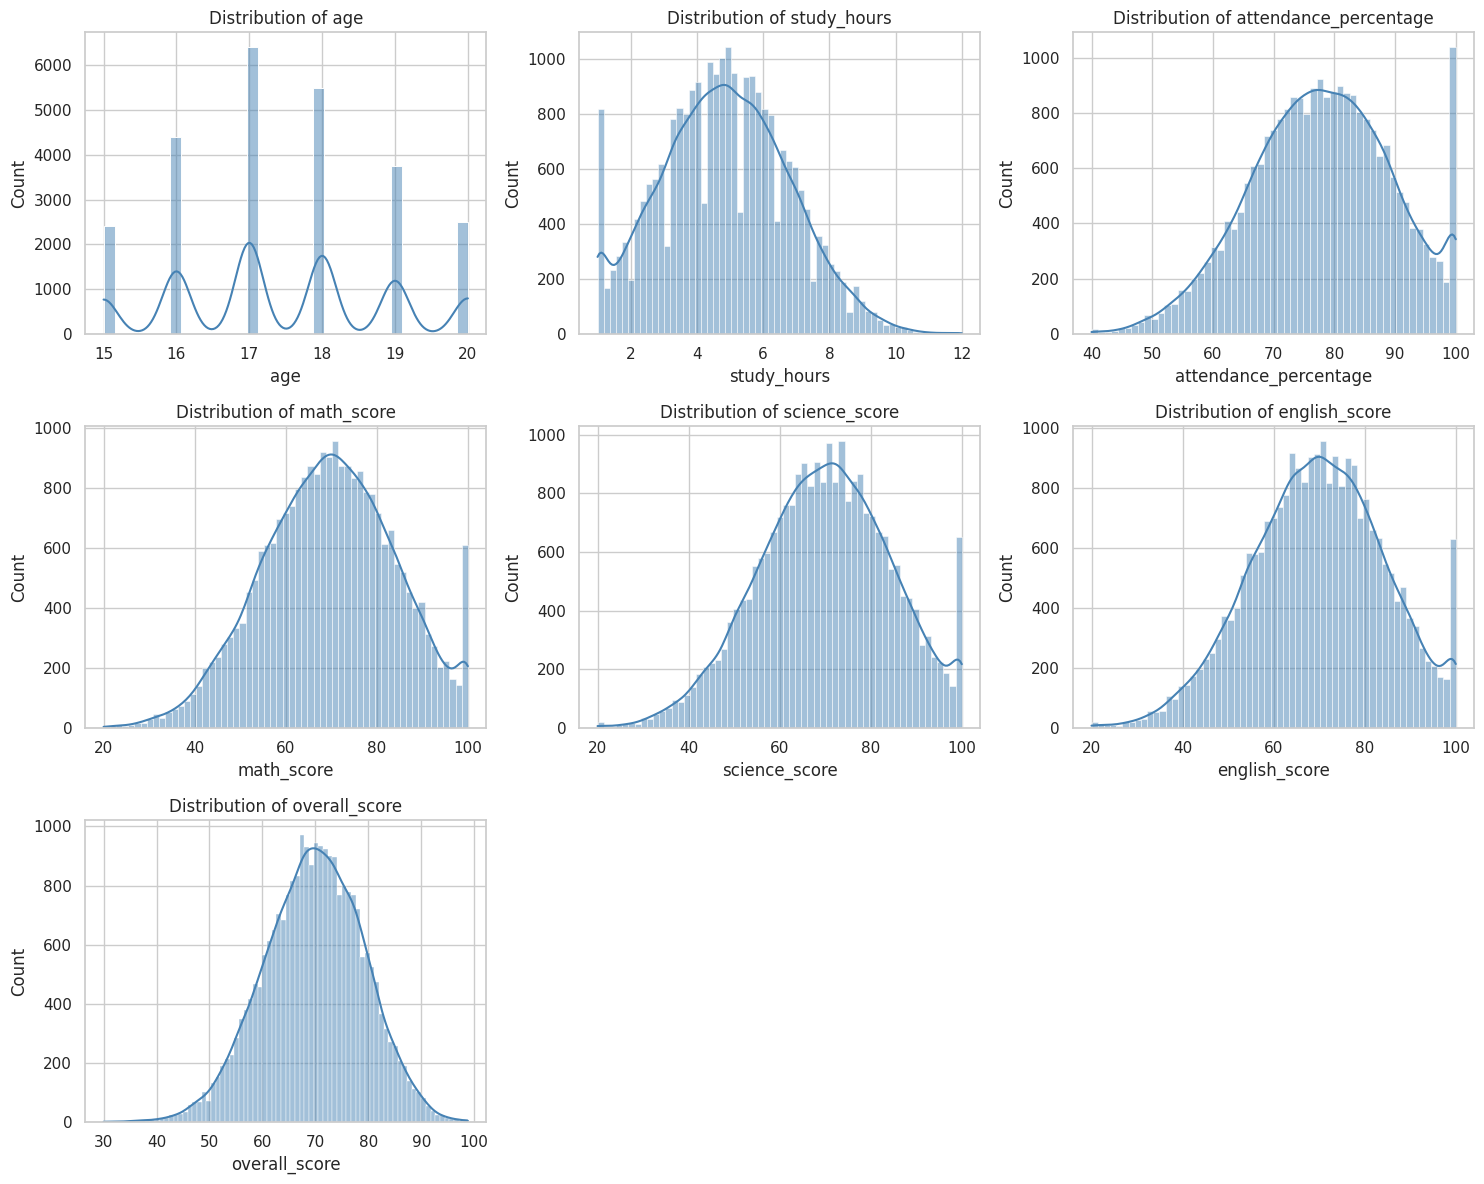

In [17]:
numeric_cols = ['age', 'study_hours', 'attendance_percentage',
                'math_score', 'science_score', 'english_score', 'overall_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5.3 Final grade distribution

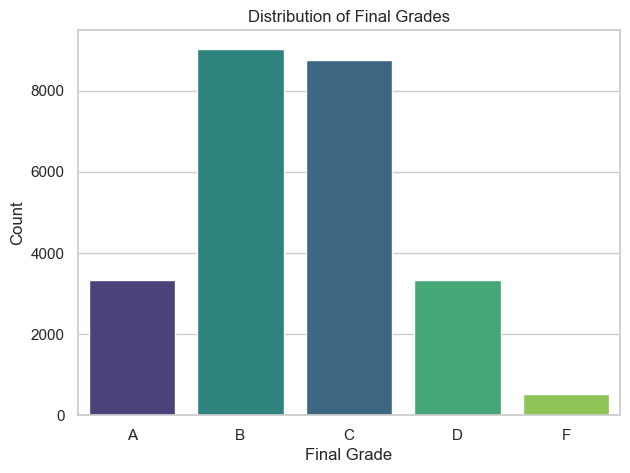

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='final_grade', order=sorted(df['final_grade'].unique()), hue='final_grade', palette='viridis')
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.show()

### 5.4 Categorical variables vs. overall score

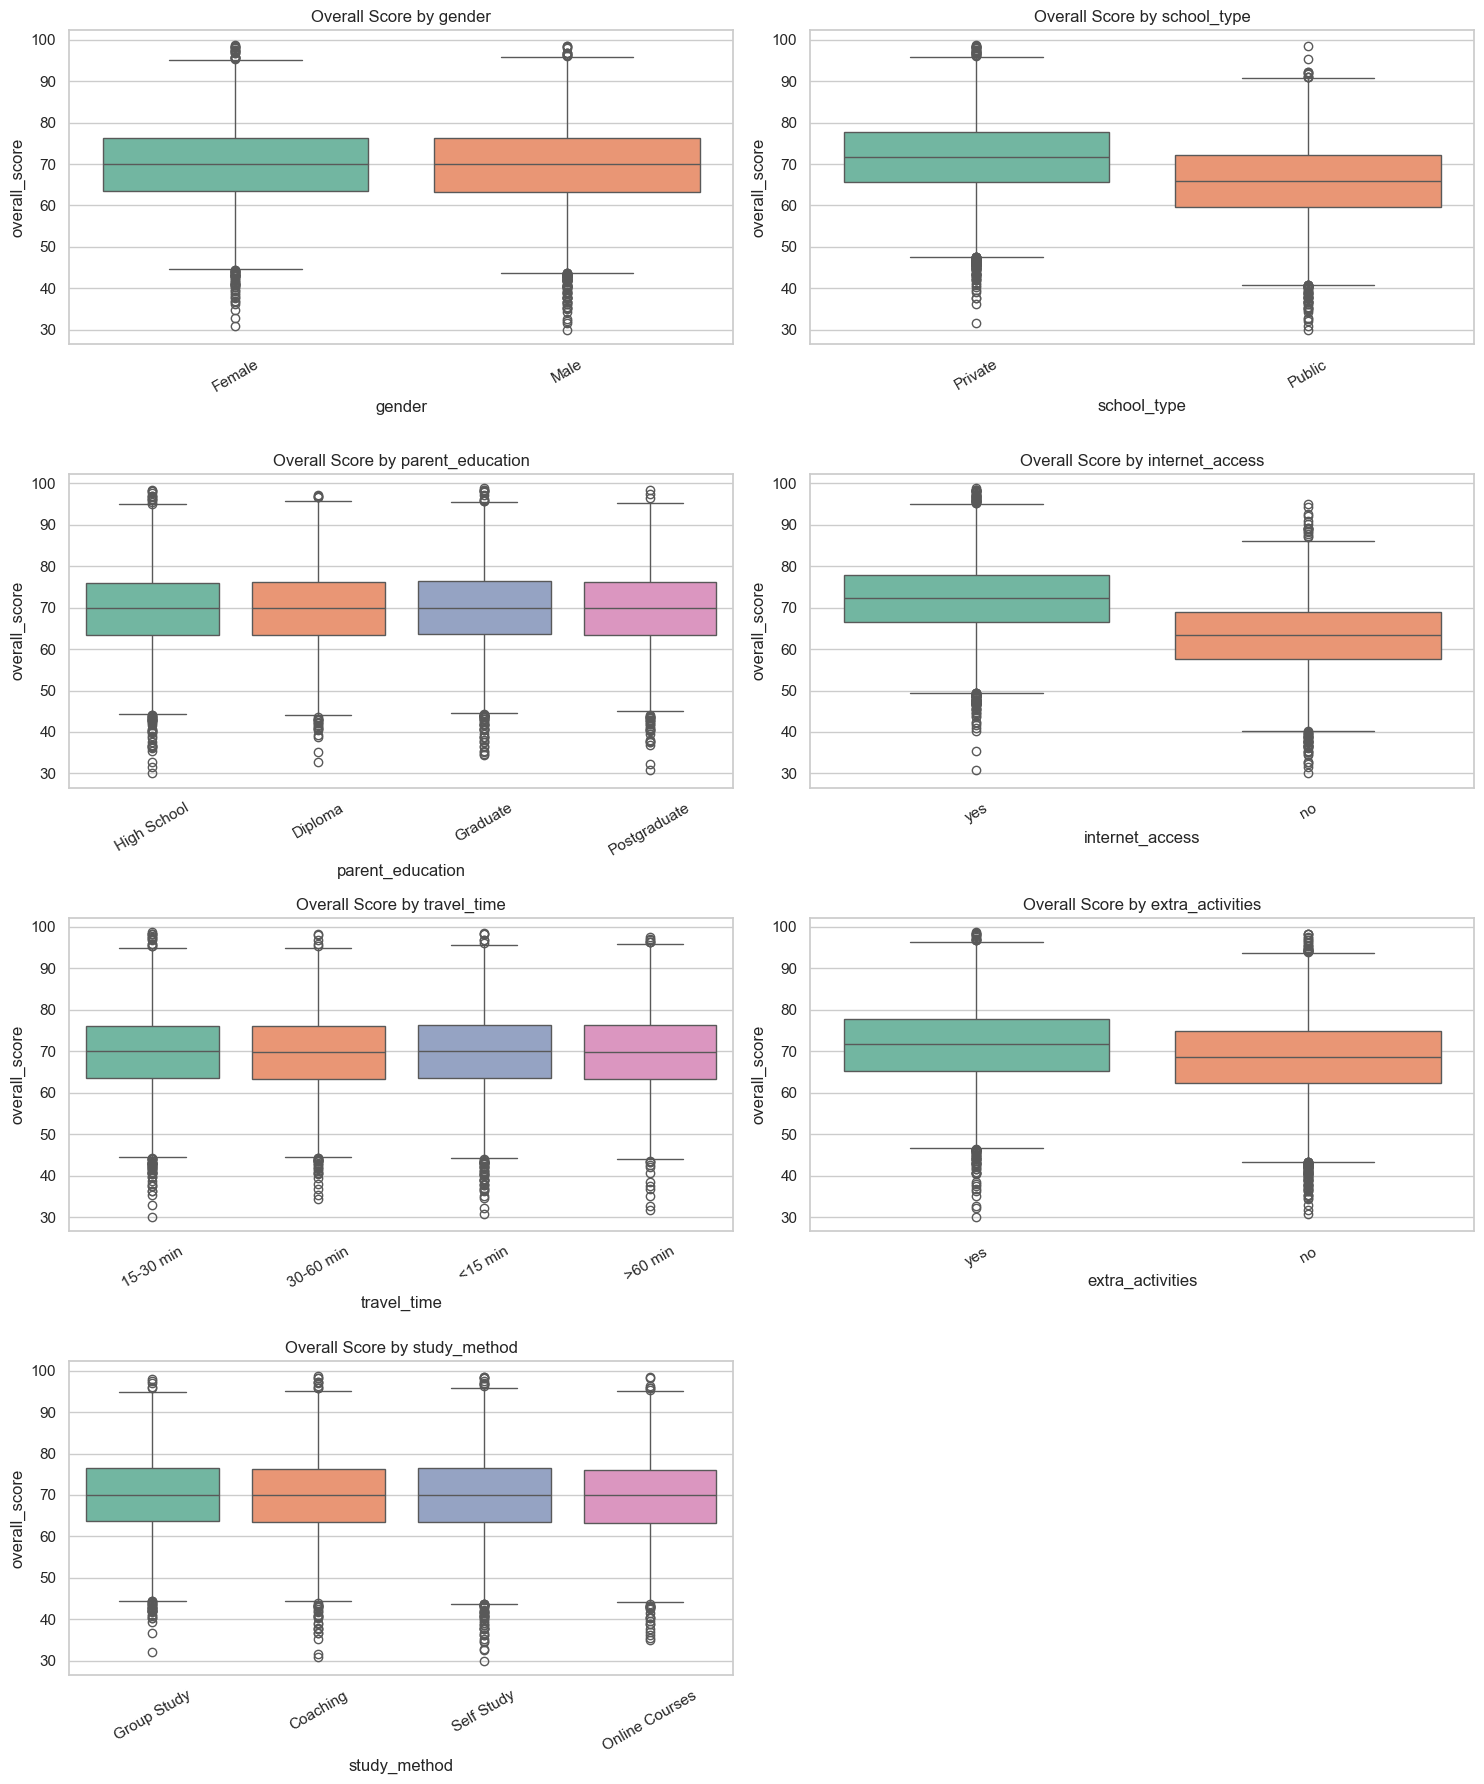

/tmp/ipykernel_584/3720122014.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='overall_score', ax=axes[i], palette='Set2')


/tmp/ipykernel_584/3720122014.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='overall_score', ax=axes[i], palette='Set2')
/tmp/ipykernel_584/3720122014.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='overall_score', ax=axes[i], palette='Set2')
/tmp/ipykernel_584/3720122014.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='overall_score', ax=axes[i], palette='Set2')


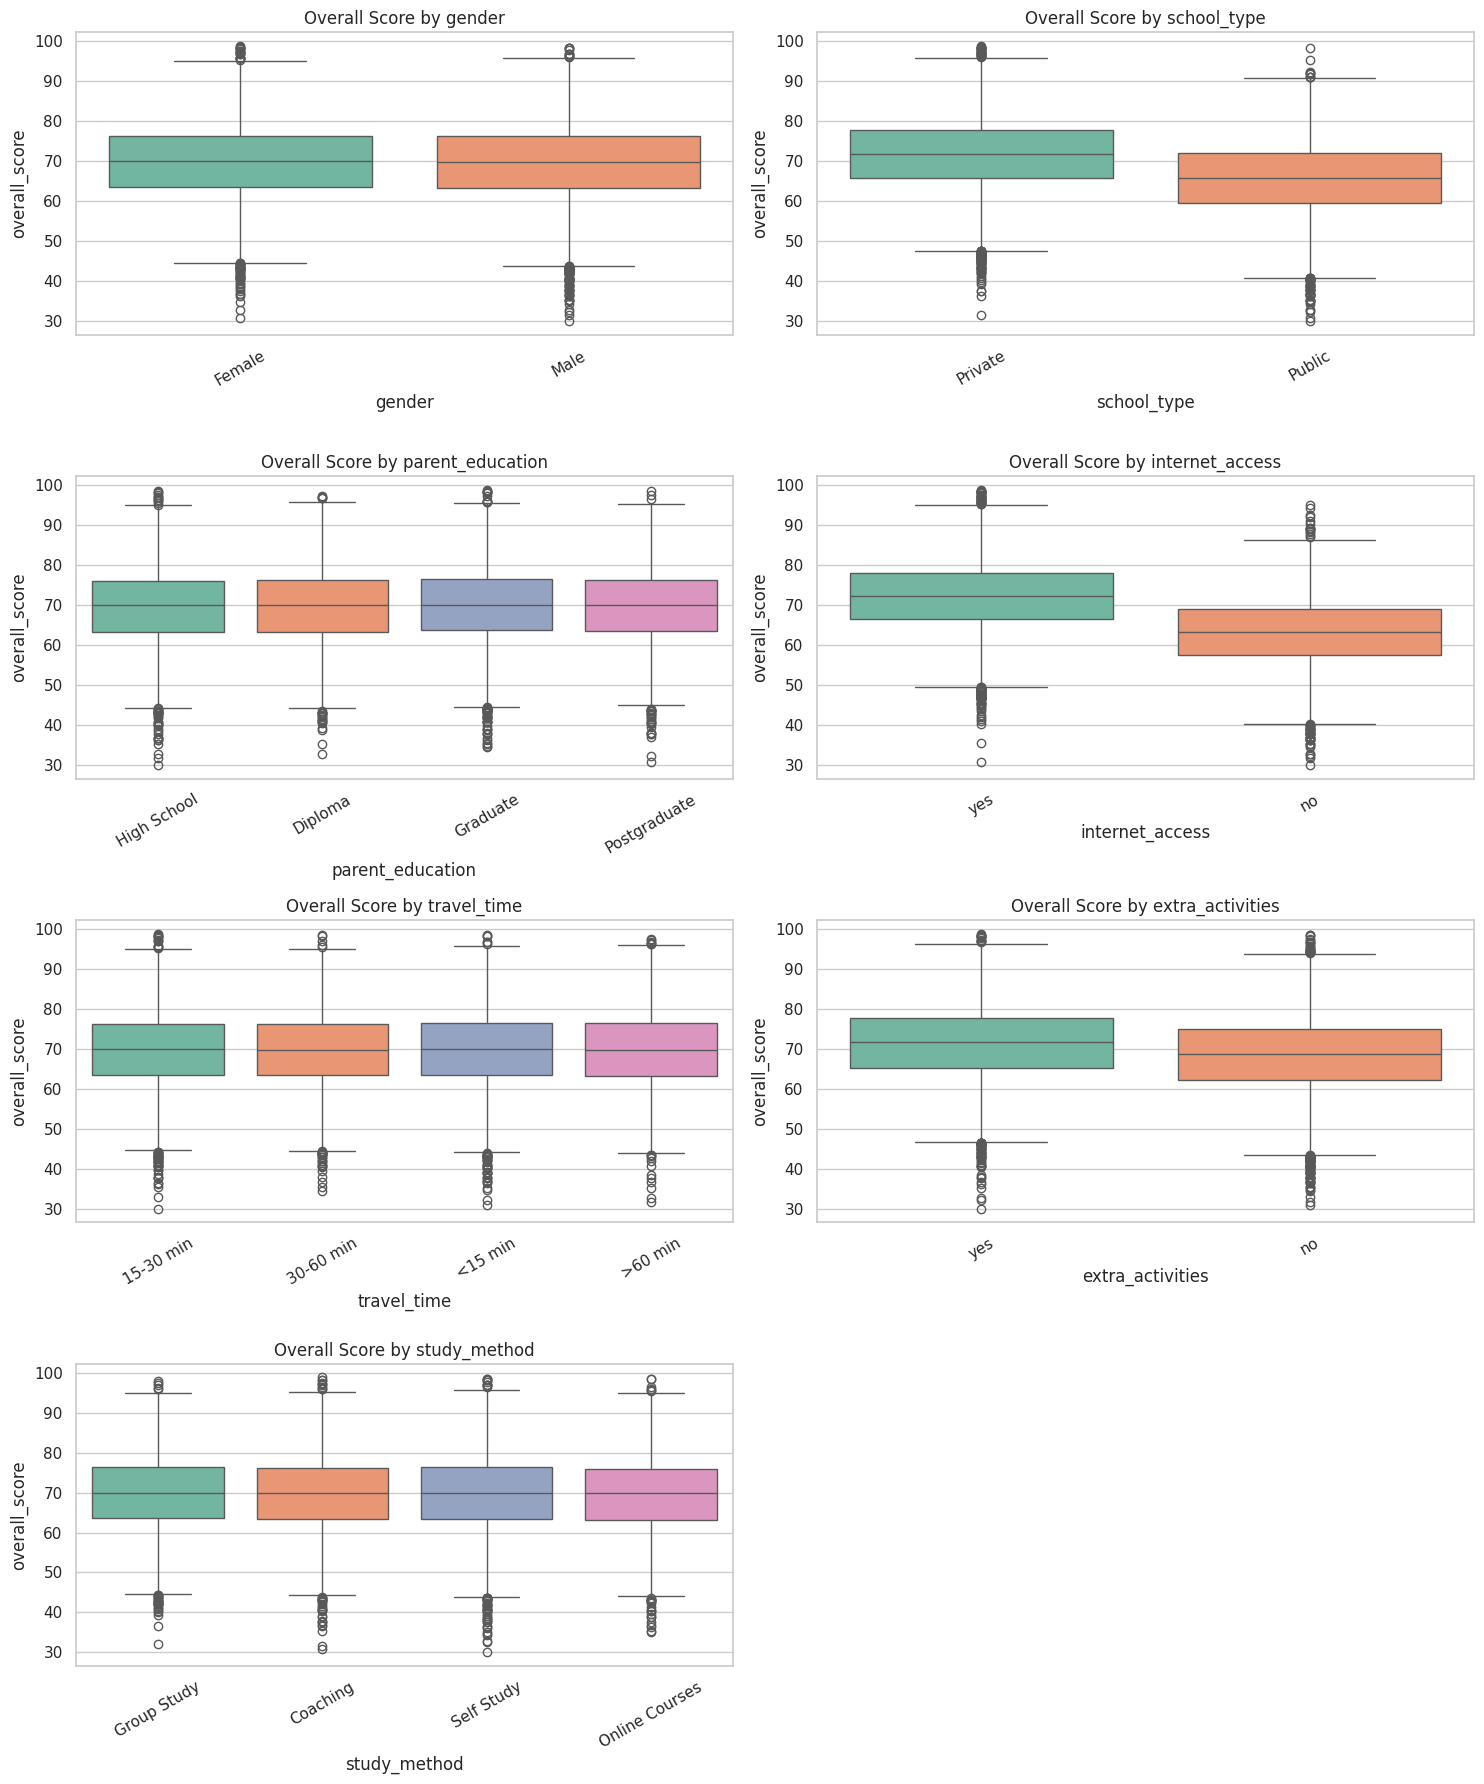

In [15]:
cat_vars = ['gender', 'school_type', 'parent_education', 'internet_access',
            'travel_time', 'extra_activities', 'study_method']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.boxplot(data=df, x=col, y='overall_score', ax=axes[i],hue=col, palette='Set2')
    axes[i].set_title(f'Overall Score by {col}')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 5.5 Correlation heatmap (numeric features)

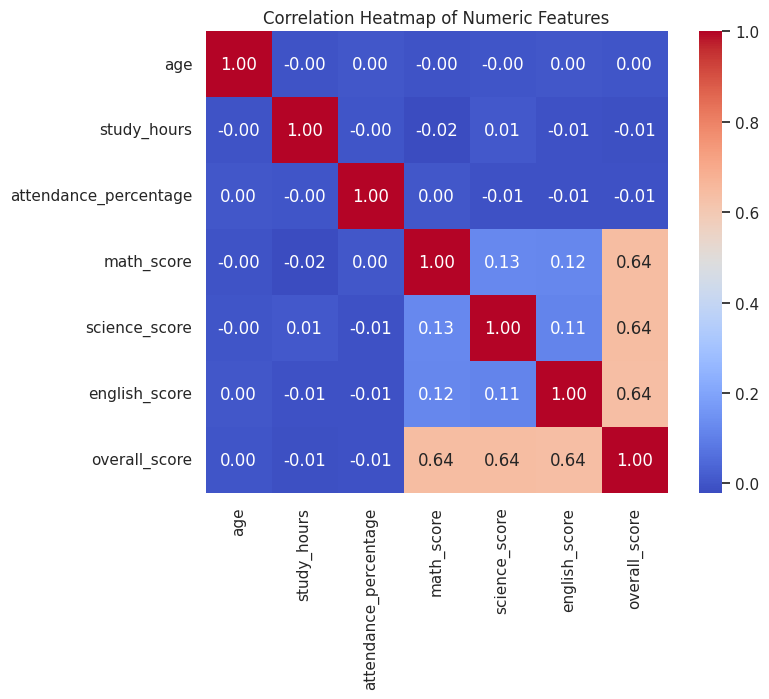

In [20]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### 5.6 Study hours vs. overall score (relationship)

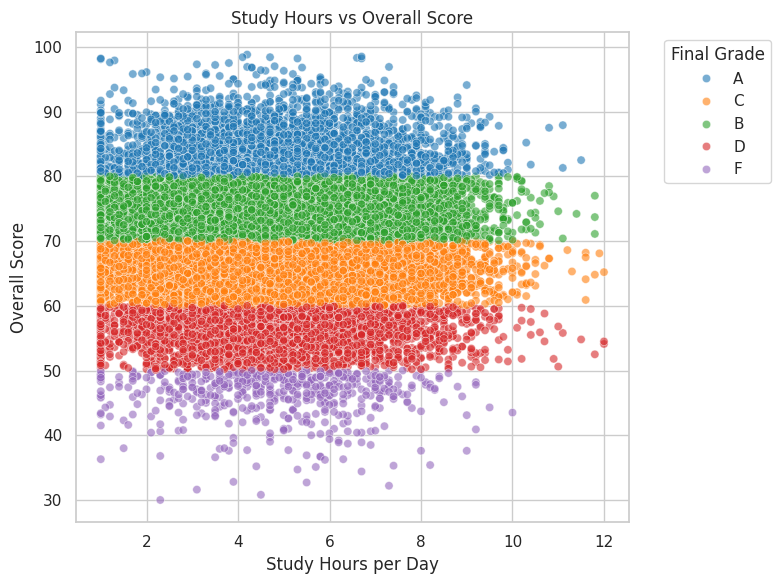

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='study_hours', y='overall_score', hue='final_grade', palette='tab10', alpha=0.6)
plt.title('Study Hours vs Overall Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Overall Score')
plt.legend(title='Final Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.7 Average scores by study method

In [22]:
score_by_method = df.groupby('study_method')[['math_score', 'science_score', 'english_score', 'overall_score']].mean().round(2)
score_by_method.sort_values('overall_score', ascending=False)

,math_score,science_score,english_score,overall_score
study_method,,,,
Group Study,69.89,69.80,69.91,69.86
Self Study,69.63,69.91,69.66,69.73
Coaching,69.50,69.89,69.50,69.63
Online Courses,69.21,69.81,69.60,69.54


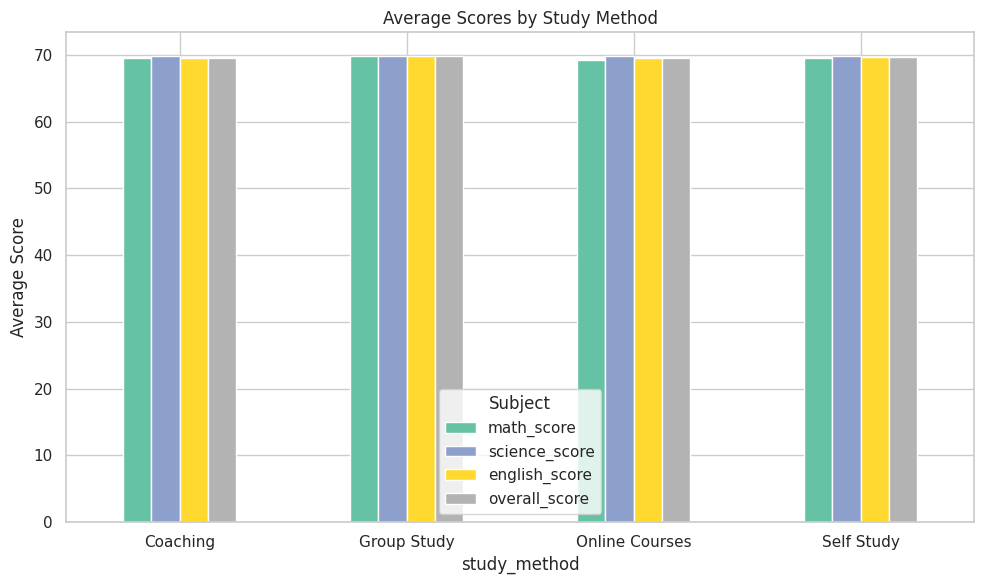

In [23]:
score_by_method.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Average Scores by Study Method')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

### 5.8 Attendance vs. final grade

/tmp/ipykernel_584/2636144490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='final_grade', y='attendance_percentage',


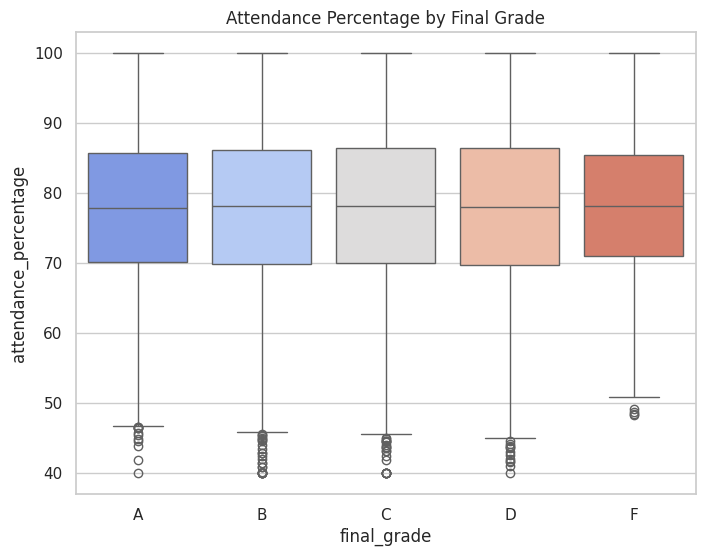

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='final_grade', y='attendance_percentage',
            order=sorted(df['final_grade'].unique()), palette='coolwarm')
plt.title('Attendance Percentage by Final Grade')
plt.show()

---
## 6. Save the cleaned dataset

Export the cleaned DataFrame to a new CSV file for further use.

In [25]:
df.to_csv("Student_Performance_Analysis_Cleaned.csv", index=False)
print("Cleaned dataset saved as 'Student_Performance_Analysis_Cleaned.csv'")

Cleaned dataset saved as 'Student_Performance_Analysis_Cleaned.csv'


---
## Summary of cleaning steps performed

1. **Duplicate rows**: checked and removed any fully duplicated rows.
2. **Duplicate IDs**: identified rows sharing the same `student_id` (flagged for review — optionally deduplicate by ID).
3. **Categorical text**: stripped whitespace and standardized values.
4. **Missing values**: filled numeric columns with median and categorical columns with mode (none were found in this dataset, but the code is reusable).
5. **Range validation**: checked and clipped score/percentage columns to a valid 0–100 range.
6. **Exported** the cleaned dataset to `Student_Performance_Analysis_Cleaned.csv`.

Feel free to add more questions/analyses below — just add new cells!

---
# Part 2: Answering 15 Key Project Questions (Interactive Visualizations)

This section uses **Plotly Express** for colorful, interactive charts (hover, zoom, legend
filtering) and avoids explicit `for` loops — vectorized pandas operations
(`groupby`, `melt`, `np.select`, `crosstab`, `corr`) and Plotly's built-in
faceting/coloring handle grouping internally.

Run the cells in Part 1 first so `df` is loaded and cleaned.

In [26]:
import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_dark"  # colorful dark theme for all charts below
VIVID = px.colors.qualitative.Vivid

## Q1: Do study hours positively impact overall performance?

**Answer:** Looking at the trendline below, the relationship is essentially flat
(correlation ≈ -0.01). In this dataset, the number of hours a student studies per day
does **not** have a meaningful positive (or negative) impact on overall score.

In [27]:
fig = px.scatter(
    df, x='study_hours', y='overall_score', color='final_grade',
    trendline='ols', opacity=0.4, color_discrete_sequence=VIVID,
    title='Q1: Study Hours vs Overall Score (with trendline)',
    labels={'study_hours': 'Study Hours per Day', 'overall_score': 'Overall Score'}
)
fig.update_traces(marker=dict(size=5))
fig.show()

## Q2: Does attendance have a strong positive relationship with scores?

**Answer:** No. The correlation between attendance percentage and overall score is
≈ -0.007 — essentially zero. Attendance alone does not strongly drive performance
in this dataset.

In [28]:
fig = px.scatter(
    df, x='attendance_percentage', y='overall_score', color='final_grade',
    trendline='ols', opacity=0.4, color_discrete_sequence=VIVID,
    title='Q2: Attendance % vs Overall Score (with trendline)',
    labels={'attendance_percentage': 'Attendance (%)', 'overall_score': 'Overall Score'}
)
fig.update_traces(marker=dict(size=5))
fig.show()

## Q3: Does internet access improve academic outcomes?

**Answer:** Yes, noticeably. Students **with** internet access average ~72.2 overall,
versus ~63.2 for those **without** — roughly a 9-point gap, the largest single-factor
gap found in this dataset.

In [29]:
fig = px.box(
    df, x='internet_access', y='overall_score', color='internet_access',
    color_discrete_sequence=VIVID, points='outliers',
    title='Q3: Overall Score by Internet Access',
    labels={'internet_access': 'Internet Access', 'overall_score': 'Overall Score'}
)
fig.show()

## Q4: Does parental education influence student achievement?

**Answer:** Only marginally. Average overall scores range from ~69.6 (High School)
to ~69.8 (Graduate) — differences of less than half a point, suggesting parental
education has little practical effect here.

In [30]:
parent_avg = df.groupby('parent_education', as_index=False)['overall_score'].mean().sort_values('overall_score')

fig = px.bar(
    parent_avg, x='parent_education', y='overall_score', color='parent_education',
    color_discrete_sequence=VIVID, text_auto='.2f',
    title='Q4: Average Overall Score by Parental Education',
    labels={'parent_education': 'Parental Education', 'overall_score': 'Avg Overall Score'}
)
fig.update_yaxes(range=[60, 75])
fig.show()

## Q5: Do certain study methods lead to better scores?

**Answer:** Differences are small but Group Study (~69.86) edges out Self Study
(~69.73), Coaching (~69.63), and Online Courses (~69.54). The spread is under
0.4 points, so study method has a minor effect.

In [31]:
method_avg = df.groupby('study_method', as_index=False)['overall_score'].mean().sort_values('overall_score')

fig = px.bar(
    method_avg, x='study_method', y='overall_score', color='study_method',
    color_discrete_sequence=VIVID, text_auto='.2f',
    title='Q5: Average Overall Score by Study Method',
    labels={'study_method': 'Study Method', 'overall_score': 'Avg Overall Score'}
)
fig.update_yaxes(range=[60, 75])
fig.show()

## Q6: Do students with shorter travel times perform better?

**Answer:** Barely. `<15 min` (~69.78) and `>60 min` (~69.75) are nearly tied at the
top, while `30-60 min` (~69.53) is slightly lower. The differences (< 0.3 points)
are not practically meaningful.

In [32]:
order = ['<15 min', '15-30 min', '30-60 min', '>60 min']
travel_avg = df.groupby('travel_time', as_index=False)['overall_score'].mean()
travel_avg['travel_time'] = pd.Categorical(travel_avg['travel_time'], categories=order, ordered=True)
travel_avg = travel_avg.sort_values('travel_time')

fig = px.bar(
    travel_avg, x='travel_time', y='overall_score', color='travel_time',
    color_discrete_sequence=VIVID, text_auto='.2f',
    title='Q6: Average Overall Score by Travel Time',
    labels={'travel_time': 'Travel Time', 'overall_score': 'Avg Overall Score'}
)
fig.update_yaxes(range=[60, 75])
fig.show()

## Q7: Does school type impact student performance?

**Answer:** Yes, substantially. Private school students average ~71.6 overall versus
~65.7 for Public school students — a gap of almost 6 points, the second-largest
factor after internet access.

In [33]:
fig = px.box(
    df, x='school_type', y='overall_score', color='school_type',
    color_discrete_sequence=VIVID, points='outliers',
    title='Q7: Overall Score by School Type',
    labels={'school_type': 'School Type', 'overall_score': 'Overall Score'}
)
fig.show()

## Q8 & Q14: How can top performers be identified for scholarships / rewards & recognition?

**Approach:** Flag students in the **top 10%** of `overall_score` (score ≥ 81.5,
the 90th percentile) as `"Top Performer"` using a vectorized `np.where` — no loop
needed. The scatter plot highlights these students, and the table below lists the
top 10 candidates with their full profile for scholarship/reward review.

In [34]:
top_threshold = df['overall_score'].quantile(0.90)
df['performance_tier'] = np.where(df['overall_score'] >= top_threshold, 'Top Performer',
                          np.where(df['overall_score'] <= df['overall_score'].quantile(0.10),
                                   'Needs Intervention', 'Average'))

fig = px.scatter(
    df, x='attendance_percentage', y='overall_score', color='performance_tier',
    color_discrete_map={'Top Performer': '#00CC96', 'Average': '#636EFA', 'Needs Intervention': '#EF553B'},
    opacity=0.5, title=f'Q8: Top Performers Highlighted (Overall Score ≥ {top_threshold:.1f})',
    labels={'attendance_percentage': 'Attendance (%)', 'overall_score': 'Overall Score'}
)
fig.update_traces(marker=dict(size=5))
fig.show()

In [35]:
# Top 10 candidates for scholarships
top10 = df.nlargest(10, 'overall_score')[
    ['student_id', 'overall_score', 'math_score', 'science_score', 'english_score',
     'attendance_percentage', 'study_hours', 'final_grade']
]
top10

,student_id,overall_score,math_score,science_score,english_score,attendance_percentage,study_hours,final_grade
1135,1136,98.8,100.0,100.0,96.5,94.8,4.2,A
22515,1261,98.5,96.7,100.0,98.8,69.2,6.7,A
3824,3825,98.4,99.4,96.3,99.5,91.7,4.1,A
16285,6317,98.4,100.0,100.0,95.3,94.1,4.7,A
12267,12268,98.3,95.0,100.0,100.0,82.3,6.6,A
8785,8786,98.2,97.0,97.6,100.0,100.0,1.0,A
13288,13289,98.2,100.0,97.2,97.3,69.6,6.7,A
23687,10491,98.2,100.0,100.0,94.5,87.1,5.3,A
2603,2604,98.1,100.0,100.0,94.2,87.1,1.0,A
17977,3875,97.9,96.8,100.0,97.0,96.6,1.3,A


In [36]:
# Q14: Profile of Top Performers - breakdown by study method (stacked bar, no loop)
tier_method = pd.crosstab(df['study_method'], df['performance_tier'], normalize='index') * 100

fig = px.bar(
    tier_method, barmode='group', color_discrete_sequence=VIVID,
    title='Q14: Performance Tier Breakdown (%) by Study Method',
    labels={'value': 'Percentage of Students (%)', 'study_method': 'Study Method', 'variable': 'Performance Tier'}
)
fig.show()

## Q9: How can low-performing students be targeted for intervention?

**Approach:** Students in the **bottom 10%** of `overall_score` (score ≤ 57.4) are
flagged `"Needs Intervention"` (computed above with `performance_tier`). The chart
below shows how many students in each `final_grade` fall into this group, and the
table lists the 10 lowest scorers for follow-up.

In [37]:
intervention_counts = df.groupby(['final_grade', 'performance_tier'], as_index=False).size()
intervention_counts = intervention_counts[intervention_counts['performance_tier'] == 'Needs Intervention']

fig = px.bar(
    intervention_counts, x='final_grade', y='size', color='final_grade',
    color_discrete_sequence=VIVID, text_auto=True,
    title='Q9: Students Flagged for Intervention, by Final Grade',
    labels={'final_grade': 'Final Grade', 'size': 'Number of Students'}
)
fig.show()

In [38]:
# 10 lowest scorers needing intervention
bottom10 = df.nsmallest(10, 'overall_score')[
    ['student_id', 'overall_score', 'math_score', 'science_score', 'english_score',
     'attendance_percentage', 'study_hours', 'final_grade']
]
bottom10

,student_id,overall_score,math_score,science_score,english_score,attendance_percentage,study_hours,final_grade
18547,3293,30.0,42.2,25.2,22.6,81.5,2.3,F
10305,10306,30.8,35.7,32.3,24.3,87.1,4.5,F
7763,7764,31.6,33.9,20.0,40.8,74.8,3.1,F
3605,3606,32.2,22.3,34.0,40.3,84.2,7.3,F
12530,12531,32.7,23.0,40.6,34.4,71.1,5.5,F
19713,12738,32.8,37.3,38.3,22.8,84.9,3.9,F
14359,14360,34.4,31.0,20.4,51.8,67.5,6.7,F
11320,11321,34.7,48.4,35.7,20.0,92.6,5.3,F
11012,11013,35.1,50.2,32.5,22.7,77.3,5.7,F
17019,3565,35.2,39.8,25.8,39.9,81.9,4.4,F


## Q10: Do Math, Science, and English scores strongly affect the overall score?

**Answer:** Yes — very strongly. Since `overall_score` is essentially the average of
the three subject scores (correlation ≈ 1.0 with their mean, and each individual
subject correlates ~0.64 with overall), all three subjects are direct, strong
drivers of the overall score.

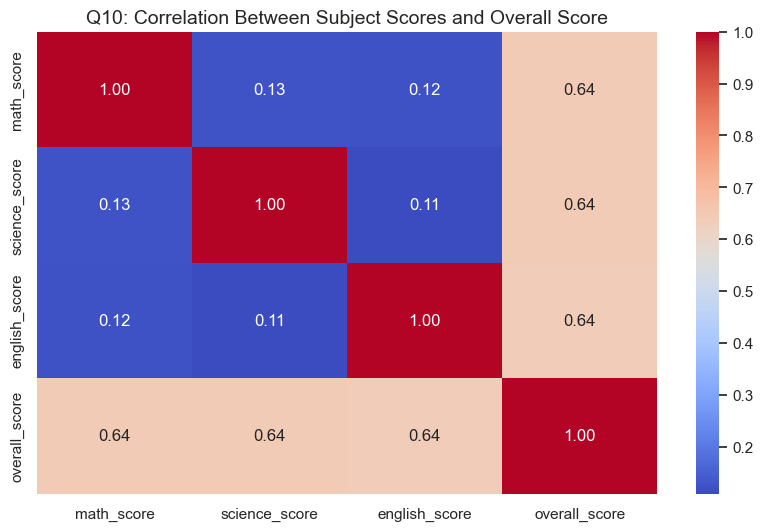

In [13]:
plt.figure(figsize=(10,6))

corr_columns = [
    'math_score',
    'science_score',
    'english_score',
    'overall_score'
]

corr_matrix = df[corr_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Q10: Correlation Between Subject Scores and Overall Score',
    fontsize=14
)

plt.show()

## Q11, Q12 & Q13: Distributions of Math, Science, and English scores

- **Q11 (Math):** Scores are roughly bell-shaped and centered around the
  60s-70s — yes, mostly concentrated in the average range.
- **Q12 (Science):** Similar shape, centered slightly above 70 — indicating
  moderate-to-strong performance overall.
- **Q13 (English):** Also roughly symmetric/bell-shaped around the 60s-70s,
  i.e. fairly evenly spread around the average rather than skewed to extremes.

The faceted histogram below (built with a single `melt` + `px.histogram` call,
no loops) compares all three side by side.

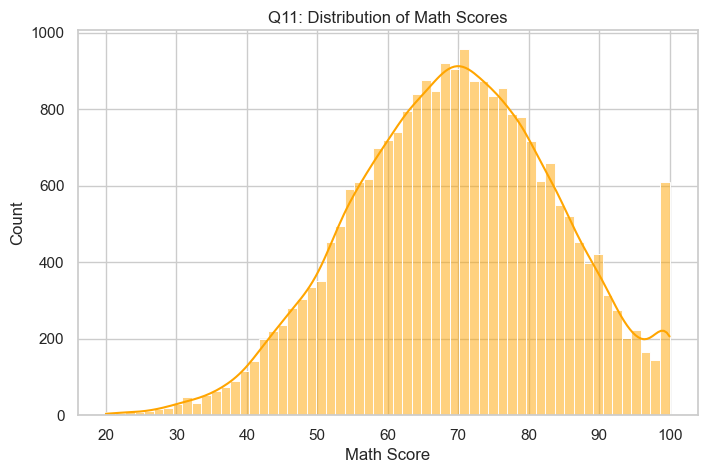

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["math_score"], kde=True, color="Orange")

plt.title("Q11: Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")

plt.show()

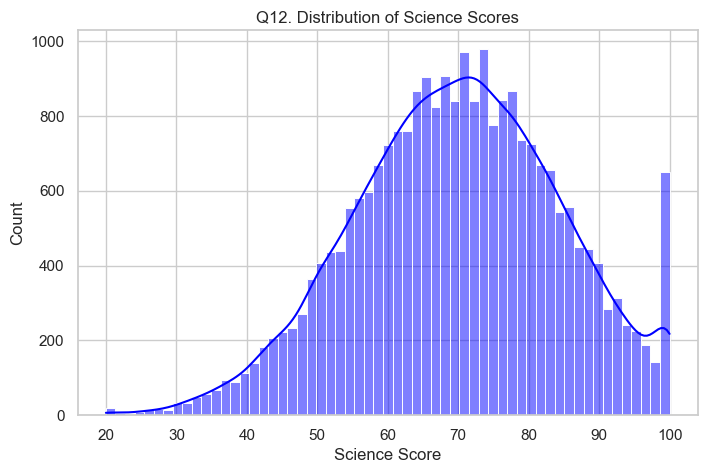

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["science_score"], kde=True, color="Blue")

plt.title("Q12. Distribution of Science Scores")
plt.xlabel("Science Score")
plt.ylabel("Count")
plt.show()

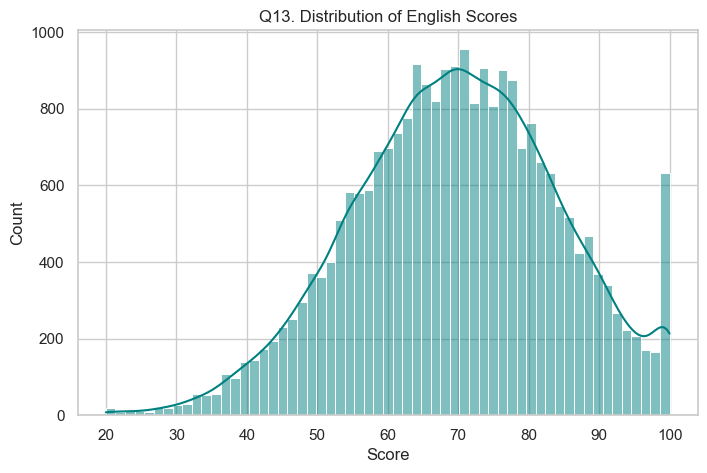

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["english_score"],
    kde=True,
    color="Teal"
)

plt.title("Q13. Distribution of English Scores")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()

## Q15: Are subject scores, attendance, and study hours the strongest predictors of overall performance?

**Answer:** Subject scores (Math, Science, English) are by far the strongest
predictors, each correlating ~0.64 with overall score. Attendance (≈ -0.007) and
study hours (≈ -0.011) show essentially **no** correlation with overall score in
this dataset — so they are *not* meaningful predictors here, despite intuition
suggesting they should be.

In [41]:
predictors = ['math_score', 'science_score', 'english_score', 'attendance_percentage', 'study_hours', 'age']
corr_with_overall = df[predictors + ['overall_score']].corr()['overall_score'].drop('overall_score').sort_values()

fig = px.bar(
    corr_with_overall, orientation='h', color=corr_with_overall.values,
    color_continuous_scale='RdYlGn',
    title='Q15: Correlation of Each Feature with Overall Score',
    labels={'value': 'Correlation with Overall Score', 'index': 'Feature', 'color': 'Correlation'}
)
fig.update_layout(coloraxis_showscale=False)
fig.show()

---
## Summary of Findings

| Question | Finding |
|---|---|
| Q1 Study hours | No meaningful impact (corr ≈ -0.01) |
| Q2 Attendance | No meaningful relationship (corr ≈ -0.01) |
| Q3 Internet access | Strong positive effect (+9 points) |
| Q4 Parental education | Negligible effect |
| Q5 Study method | Minor effect (Group Study slightly best) |
| Q6 Travel time | Negligible effect |
| Q7 School type | Strong effect — Private +5.8 points over Public |
| Q8/Q14 Top performers | Top 10% (score ≥ 81.5) identifiable via `performance_tier` flag |
| Q9 At-risk students | Bottom 10% (score ≤ 57.4) identifiable for intervention |
| Q10 Subject scores | Overall score = average of Math/Science/English (corr ≈ 1.0) |
| Q11-13 Subject distributions | All roughly bell-shaped, centered in 60-75 range |
| Q15 Strongest predictors | Subject scores dominate; attendance/study hours are not predictive |

**Key takeaway:** In this dataset, the biggest performance drivers are
**internet access** and **school type**, while **study hours** and
**attendance** show no measurable relationship with outcomes — worth flagging
to stakeholders, as it's a counter-intuitive but data-driven result.